# Binary Images and Thresholding

##  Overview

**Binary images** are digital images that contain only two possible pixel values:

- **0 → Black**
- **1 (or 255) → White**

In binary images, each pixel belongs to one of two categories:
- **Foreground** (object of interest)
- **Background**

Because of this simplicity, binary images are widely used in image processing, computer vision, medical imaging, and pattern recognition.

---

##  What Is Thresholding?

**Thresholding** is a technique used to convert a grayscale image into a binary image.

In grayscale images, pixel intensity values range from:

- **0 → Black**
- **255 → White**

Thresholding selects a specific value called the **threshold (T)** and classifies pixels according to this rule:



<div style="direction:rtl;text-align:right;font-family:Tahoma">
در ابتدا با numpy تصویر را باینری می‌کنیم.
</div>

### Thresholding Decision Rule

The binary classification of each pixel is defined as:


B(x, y) =
\begin{cases}
1 & \text{if } I(x, y) \geq T \\
0 & \text{if } I(x, y) < T
\end{cases}


### Explanation

- **\( I(x, y) \)** → Intensity value of the pixel at position \((x, y)\) in the grayscale image  
- **\( T \)** → Threshold value  
- **\( B(x, y) \)** → Output binary image  

### Interpretation

- If the pixel intensity is **greater than or equal to the threshold**, the pixel is assigned:
  - **1 (White)** → Typically represents the **foreground (object of interest)**  

- If the pixel intensity is **less than the threshold**, the pixel is assigned:
  - **0 (Black)** → Typically represents the **background**  

This rule converts a grayscale image into a binary image by separating objects from the background based on intensity.



Where:
- `I(x, y)` is the pixel intensity at location `(x, y)`
- `T` is the threshold value

---

##  Types of Thresholding and Their Usage

### 1️⃣ Global Thresholding

### Description
A single threshold value is applied to the entire image.

### When to Use
- Images with uniform lighting
- Document scanning
- Preprocessing for OCR
- Simple object detection

### Advantages
- Simple
- Fast
- Low computational cost

### Limitations
- Sensitive to uneven illumination
- Not suitable for complex lighting conditions

---

### 2️⃣ Adaptive Thresholding

### Description
Different threshold values are computed for different regions of the image.

Instead of one global value, the threshold depends on local neighborhood statistics (mean or Gaussian-weighted average).

### When to Use
- Uneven lighting conditions
- Outdoor scenes
- Medical images
- Real-world surveillance images

### Advantages
- Handles illumination variations well
- More accurate segmentation in complex images

### Limitations
- Higher computational cost
- Parameter tuning may be required

---

### 3️⃣ Otsu’s Thresholding

### Description
An automatic threshold selection method that determines the optimal threshold by minimizing **intra-class variance** (or maximizing inter-class variance).

It assumes the image histogram has two peaks (bimodal distribution).

### When to Use
- Automated systems
- Industrial inspection
- Biomedical image segmentation
- When manual threshold selection is not practical

### Advantages
- Fully automatic
- No manual parameter tuning

### Limitations
- Works best when histogram has two distinct intensity peaks
- Less effective for multimodal distributions

---

##  Applications of Binary Images

Binary images are commonly used in:

- Object detection
- Edge detection
- Medical image segmentation (tumor detection, organ boundary extraction)
- Optical Character Recognition (OCR)
- Fingerprint recognition
- Shape analysis
- Morphological operations (erosion, dilation, opening, closing)
- Region extraction and contour detection

---

##  Why Binary Images Are Important

Binary images:

- Reduce computational complexity
- Simplify image representation
- Improve processing speed
- Highlight important structures
- Serve as input for higher-level computer vision algorithms
- Enable morphological processing

---

##  Summary

Binary images and thresholding are fundamental techniques in image processing.

Thresholding transforms grayscale images into simplified binary forms, enabling:

- Efficient segmentation
- Object extraction
- Feature analysis
- Preprocessing for advanced AI and computer vision systems

They form the foundation of many practical applications in engineering, healthcare, biometrics, and automated inspection systems.


# Binary Thresholding — Python / OpenCV Implementation  
and Visual Diagram Explanation

---

##  1️⃣ Python / OpenCV Implementation

###  Step 1: Import Libraries

```python
import cv2
import numpy as np
from matplotlib import pyplot as plt


##Step 2: Read Image in Grayscale

```python
# Read image
image = cv2.imread("image.jpg", cv2.IMREAD_GRAYSCALE)


cv2.IMREAD_GRAYSCALE ensures the image is loaded as a single-channel grayscale image.

## A) Global Thresholding

In [ ]:
# Apply global threshold
T = 127
_, binary = cv2.threshold(image, T, 255, cv2.THRESH_BINARY)

# Display results
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')

plt.subplot(1,2,2)
plt.title("Binary Image (Global Threshold)")
plt.imshow(binary, cmap='gray')
plt.show()


##  Explanation of Thresholding Parameters in OpenCV

###  `T = 127` → Threshold Value

- `T` represents the cutoff intensity used to separate foreground from background.
- In an 8-bit grayscale image, pixel values range from **0 to 255**.
- Choosing `T = 127` places the threshold roughly in the middle of the intensity range.
- Any pixel intensity is compared against this value to determine whether it becomes black or white in the binary image.

---

###  `255` → Maximum Value Assigned to White Pixels

- The value `255` represents **pure white** in an 8-bit image.
- When a pixel satisfies the threshold condition, it is assigned this value.
- Since OpenCV uses 8-bit images by default, white = 255 and black = 0.

This means the output binary image contains only two values:



## B) Adaptive Thresholding

In [ ]:
adaptive = cv2.adaptiveThreshold(
    image,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,   # Block size
    2     # Constant subtracted from mean
)

plt.imshow(adaptive, cmap='gray')
plt.title("Adaptive Thresholding")
plt.show()


##  Explanation of Adaptive Thresholding Parameters in OpenCV

###  Threshold is calculated locally for each region

- Unlike global thresholding, **adaptive thresholding computes a separate threshold for each small area** of the image.
- This allows the method to handle **uneven illumination** or shadows.
- Each pixel is compared to a threshold that is derived from the surrounding neighborhood.

---

###  `11` → Size of Local Neighborhood (Block Size)

- This is the **width and height of the square neighborhood** around each pixel used to compute the local threshold.
- Example: If `11`, then a pixel’s threshold is computed using the **11×11 pixels surrounding it**.
- Larger block sizes smooth out variations but may lose fine details.
- Smaller block sizes capture fine details but may be sensitive to noise.

---

###  `2` → Constant Subtracted from the Mean

- After computing the local mean (or Gaussian-weighted mean) of the neighborhood, **this constant `C` is subtracted** to fine-tune the threshold:

$$
T_{local} = \text{Mean of neighborhood} - C
$$

- Example: If local mean = 130 and C = 2 → Threshold = 128
- Adjusting `C` changes how strict the threshold is:
  - Higher `C` → More pixels become black
  - Lower `C` → More pixels become white

---

###  Conceptual Understanding

Adaptive thresholding essentially acts like **local decision-making** for each region:

- Handles varying lighting conditions
- Preserves object details in unevenly illuminated areas
- More robust than global thresholding for real-world images


## C) Otsu’s Thresholding (Automatic)

In [ ]:
_, otsu = cv2.threshold(
    image,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.imshow(otsu, cmap='gray')
plt.title("Otsu Thresholding")
plt.show()


##  Explanation of Otsu’s Thresholding

###  Threshold is automatically selected

- Otsu’s method **analyzes the grayscale histogram** of the image and chooses the optimal threshold `T` that **minimizes intra-class variance** (variance within foreground and background).
- It separates the pixel intensities into two distinct classes: foreground and background, automatically finding the value that best divides them.

---

###  No need to manually choose `T`

- Unlike global thresholding, you **do not have to specify a threshold value**.
- OpenCV automatically calculates it using:

```python
_, otsu = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)


##  Conceptual Understanding of Otsu’s Method

Otsu’s thresholding can be thought of as an **automatic classifier** that separates an image into two classes: foreground and background.

### Input
- Grayscale image with pixel intensities ranging from 0 to 255.

### Output
- **Optimal threshold `T`** automatically computed from the histogram.
- **Binary image** where:
  - Pixels ≥ `T` → White (Foreground)
  - Pixels < `T` → Black (Background)

### Common Applications
- **Biomedical image segmentation**  
  Detecting organs, tumors, or other structures in medical scans.

- **Industrial inspection**  
  Identifying defects, objects, or features in manufactured products.

- **Automated preprocessing**  
  Preparing images for OCR, computer vision pipelines, or machine learning without manual intervention.

### Key Advantage
- No need to manually choose a threshold value.
- Robust for images with **bimodal intensity distributions**.


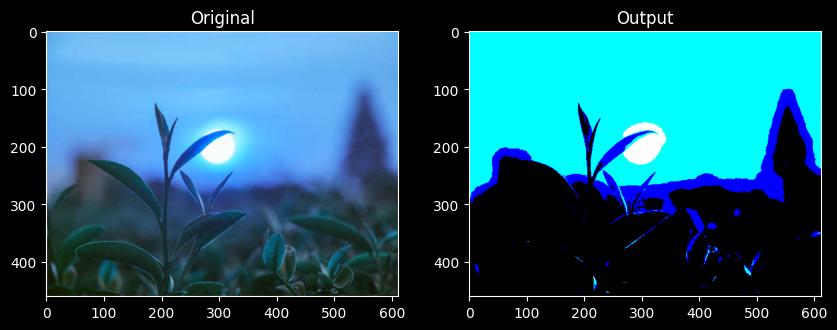

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load our image as greyscale
image = cv2.imread("C:/Users/sudob/OneDrive/Desktop/week4/image.jpg")

new_image = np.copy(image)
new_image[new_image <  127] = 0
new_image[new_image >= 127] = 255


plt.figure(figsize=[10,5])
plt.subplot(121);plt.imshow(image, cmap='gray');plt.title("Original");
plt.subplot(122);plt.imshow(new_image, cmap='gray');plt.title("Output");

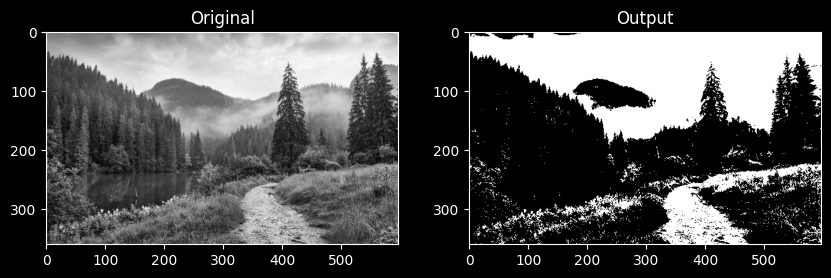

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load our image as greyscale
image = cv2.imread("C:/Users/sudob/OneDrive/Desktop/week4/nature.jpg", 0)

new_image = np.copy(image)
new_image[new_image <  127] = 0
new_image[new_image >= 127] = 255

plt.figure(figsize=[10,5])
plt.subplot(121);plt.imshow(image, cmap='gray');plt.title("Original");
plt.subplot(122);plt.imshow(new_image, cmap='gray');plt.title("Output");

For this task, we can use the **`threshold`** function in OpenCV.

### 🔹 Explanation

- The `threshold` function in OpenCV converts a **grayscale image** into a **binary image** based on a specified threshold value or method (global, adaptive, or Otsu).  
- It returns two outputs:
  1. The threshold value actually used (`T`)  
  2. The resulting binary image

`threshold(src, thresh, maxval, type[, dst])`

`maxval` : maximum value to use with the #THRESH_BINARY and #THRESH_BINARY_INV thresholding

127.0


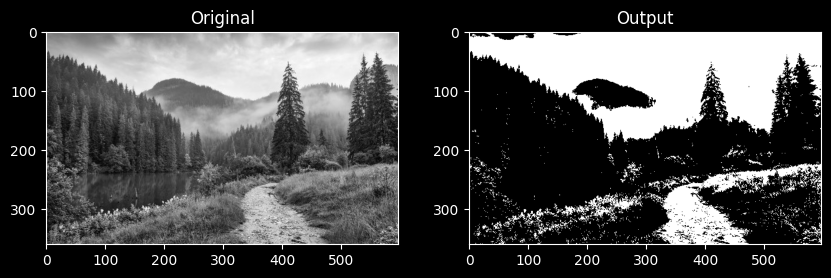

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load our image as greyscale
image = cv2.imread("C:/Users/sudob/OneDrive/Desktop/week4/nature.jpg",0)

# Values below 127 goes to 0 (black, everything above goes to 255 (white)
ret,new_image = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
print(ret)
plt.figure(figsize=[10,5])
plt.subplot(121);plt.imshow(image, cmap='gray');plt.title("Original");
plt.subplot(122);plt.imshow(new_image, cmap='gray');plt.title("Output");

**Different Parameters of the `threshold` Function**

### 🔹 Syntax in OpenCV (Python)

```python
retval, dst = cv2.threshold(src, thresh, maxval, type)

## 🔹 Parameters Explained for `cv2.threshold()`

| **Parameter** | **Description** |
|---------------|----------------|
| `src`         | Input grayscale image that you want to threshold. |
| `thresh`      | Threshold value `T` used for **global thresholding**. Pixels are compared to this value. |
| `maxval`      | Maximum value assigned to pixels **above the threshold** (typically 255 for white). |
| `type`        | Type of thresholding to apply, e.g.:<br>• `cv2.THRESH_BINARY` – Standard binary thresholding<br>• `cv2.THRESH_BINARY_INV` – Inverted binary thresholding<br>• `cv2.THRESH_OTSU` – Automatic threshold selection |
| `retval`      | The threshold value actually used. For Otsu’s method, this is **computed automatically**. |
| `dst`         | Output **binary image** after thresholding. |


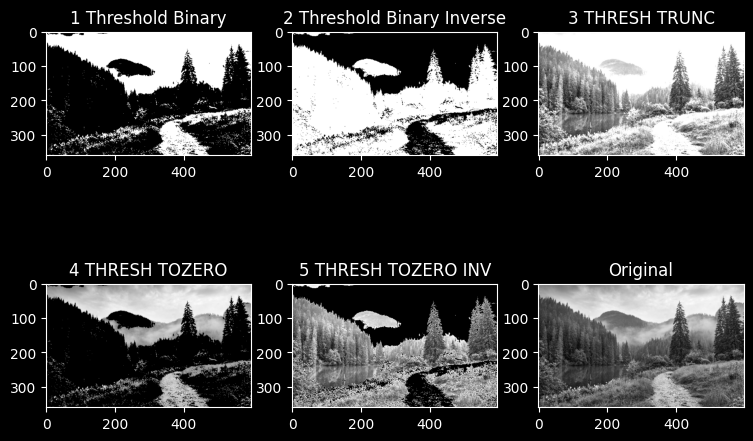

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load our image as greyscale
image = cv2.imread("C:/Users/sudob/OneDrive/Desktop/week4/nature.jpg",0)

# Values below 127 goes to 0 (black, everything above goes to 255 (white)
ret1,thresh1 = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

# Values below 127 go to 255 and values above 127 go to 0 (reverse of above)
ret2,thresh2 = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY_INV)

# Values above 127 are truncated (held) at 127 (the 255 argument is unused)
ret3,thresh3 = cv2.threshold(image, 127, 255, cv2.THRESH_TRUNC)

# Values below 127 go to 0, above 127 are unchanged
ret4,thresh4 = cv2.threshold(image, 127, 255, cv2.THRESH_TOZERO)

# Resever of above, below 127 is unchanged, above 127 goes to 0
ret5,thresh5 = cv2.threshold(image, 127, 255, cv2.THRESH_TOZERO_INV)

plt.figure(figsize=[9,6])
plt.subplot(231);plt.imshow(thresh1, cmap='gray');plt.title("1 Threshold Binary");
plt.subplot(232);plt.imshow(thresh2, cmap='gray');plt.title("2 Threshold Binary Inverse");
plt.subplot(233);plt.imshow(thresh3, cmap='gray');plt.title("3 THRESH TRUNC");
plt.subplot(234);plt.imshow(thresh4, cmap='gray');plt.title("4 THRESH TOZERO");
plt.subplot(235);plt.imshow(thresh5, cmap='gray');plt.title("5 THRESH TOZERO INV");
plt.subplot(236);plt.imshow(image, cmap='gray');plt.title("Original");



## Applying Thresholding with Different Methods on a Car License Plate Image**

### 🔹 Description

This example demonstrates how to apply **different thresholding methods** (global, adaptive, and Otsu) to a grayscale image of a car license plate.  
The goal is to **highlight the characters** on the plate for easier detection and recognition.

---

### 🔹 Python / OpenCV Example

```python
import cv2
from matplotlib import pyplot as plt

# Load image in grayscale
image = cv2.imread("car_plate.jpg", cv2.IMREAD_GRAYSCALE)

# 1️⃣ Global Thresholding
_, binary_global = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

# 2️⃣ Adaptive Thresholding
binary_adaptive = cv2.adaptiveThreshold(
    image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY, 11, 2
)

# 3️⃣ Otsu's Thresholding
_, binary_otsu = cv2.threshold(
    image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# Display results
plt.figure(figsize=(12,6))

plt.subplot(1,4,1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(binary_global, cmap='gray')
plt.title("Global Threshold")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(binary_adaptive, cmap='gray')
plt.title("Adaptive Threshold")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(binary_otsu, cmap='gray')
plt.title("Otsu Threshold")
plt.axis('off')

plt.show()


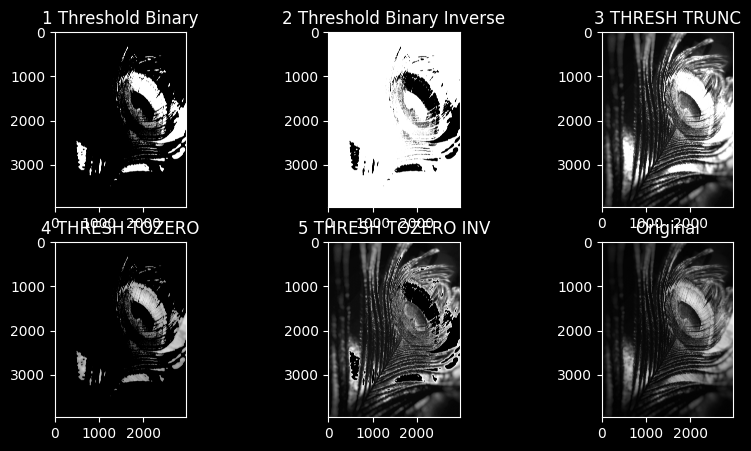

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load our image as greyscale
image = cv2.imread("C:/Users/sudob/OneDrive/Desktop/week4/pexels-photo-674010.jpeg",0)
cv2.imshow('Original', image)

# Values below 127 goes to 0 (black, everything above goes to 255 (white)
ret1,thresh1 = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

# Values below 127 go to 255 and values above 127 go to 0 (reverse of above)
ret2,thresh2 = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY_INV)

# Values above 127 are truncated (held) at 127 (the 255 argument is unused)
ret3,thresh3 = cv2.threshold(image, 127, 255, cv2.THRESH_TRUNC)

# Values below 127 go to 0, above 127 are unchanged
ret4,thresh4 = cv2.threshold(image, 127, 255, cv2.THRESH_TOZERO)

# Resever of above, below 127 is unchanged, above 127 goes to 0
ret5,thresh5 = cv2.threshold(image, 127, 255, cv2.THRESH_TOZERO_INV)

plt.figure(figsize=[10,5])
plt.subplot(231);plt.imshow(thresh1, cmap='gray');plt.title("1 Threshold Binary");
plt.subplot(232);plt.imshow(thresh2, cmap='gray');plt.title("2 Threshold Binary Inverse");
plt.subplot(233);plt.imshow(thresh3, cmap='gray');plt.title("3 THRESH TRUNC");
plt.subplot(234);plt.imshow(thresh4, cmap='gray');plt.title("4 THRESH TOZERO");
plt.subplot(235);plt.imshow(thresh5, cmap='gray');plt.title("5 THRESH TOZERO INV");
plt.subplot(236);plt.imshow(image, cmap='gray');plt.title("Original");

#Applying Thresholding with a User Interface (UI)**

### 🔹 Description

Instead of hardcoding threshold values in the code, we can **create an interactive UI** where the user can adjust parameters like:

- Threshold value (`T`) for global thresholding  
- Block size and constant (`C`) for adaptive thresholding  
- Choice of thresholding method (Global, Adaptive, Otsu)  

This allows **real-time visualization** of how different parameters affect the binary output.

---

### 🔹 Python / OpenCV Example with Trackbars

```python
import cv2

# Load grayscale image
image = cv2.imread("car_plate.jpg", cv2.IMREAD_GRAYSCALE)

# Callback function for trackbar (does nothing)
def nothing(x):
    pass

# Create a window
cv2.namedWindow("Thresholding UI")

# Create trackbars
cv2.createTrackbar("Threshold", "Thresholding UI", 127, 255, nothing)
cv2.createTrackbar("Max Value", "Thresholding UI", 255, 255, nothing)

while True:
    # Get current trackbar positions
    T = cv2.getTrackbarPos("Threshold", "Thresholding UI")
    max_val = cv2.getTrackbarPos("Max Value", "Thresholding UI")
    
    # Apply global threshold
    _, binary = cv2.threshold(image, T, max_val, cv2.THRESH_BINARY)
    
    # Display result
    cv2.imshow("Thresholding UI", binary)
    
    # Exit on 'q' key
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cv2.destroyAllWindows()


error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:868: error: (-215:Assertion failed) trackbar in function 'cv::getTrackbarPos'


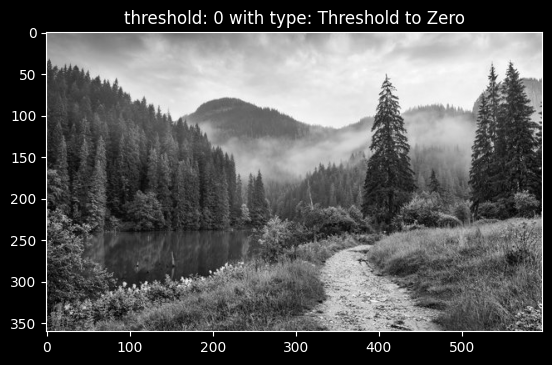

In [1]:
import cv2
import matplotlib.pyplot as plt

max_value = 255
max_type = 4
max_binary_value = 255
trackbar_type = 'Type: \n 0: Binary \n 1: Binary Inverted \n 2: Truncate \n 3: To Zero \n 4: To Zero Inverted'
trackbar_value = 'Value'
window_name = 'Threshold Demo'
def Threshold_Demo(val):
    global dst, threshold_value, threshold_type
    #0: Binary
    #1: Binary Inverted
    #2: Threshold Truncated
    #3: Threshold to Zero
    #4: Threshold to Zero Inverted
    threshold_type = cv2.getTrackbarPos(trackbar_type, window_name)
    threshold_value = cv2.getTrackbarPos(trackbar_value, window_name)
    _, dst = cv2.threshold(src_gray, threshold_value, max_binary_value, threshold_type )
    cv2.imshow(window_name, dst)

src = cv2.imread("C:/Users/sudob/OneDrive/Desktop/week4/nature.jpg" )

# Convert the image to Gray
src_gray = cv2.cvtColor(src, cv2.COLOR_BGR2GRAY)
cv2.namedWindow(window_name,cv2.WINDOW_NORMAL)
cv2.resizeWindow(window_name, 400, 300)# Resize window to specified dimensions
cv2.createTrackbar(trackbar_type, window_name , 3, max_type, Threshold_Demo)
# Create Trackbar to choose Threshold value
cv2.createTrackbar(trackbar_value, window_name , 0, max_value, Threshold_Demo)
# Call the function to initialize
Threshold_Demo(0)
# Wait until user finishes program
cv2.waitKey()
cv2.destroyAllWindows()

thresh_type= ["Binary","Binary Inverted","Threshold Truncated","Threshold to Zero","Threshold to Zero Inverted"]
plt.imshow(dst, cmap='gray');plt.title("threshold: {} with type: {}".format(threshold_value, thresh_type[threshold_type]))
plt.show()

https://docs.opencv.org/4.x/db/d8e/tutorial_threshold.html